# PennyLane Practice

In [26]:
import pennylane as qml
from pennylane import numpy as np
from IPython import display

## Device
Quantum circuit creation: The program creates a quantum circuit using the qml.qnode decorator and the dev device object.

In [27]:
dev = qml.device('default.qubit', wires=1)

## QNode
The qml.qnode decorator is a function provided by PennyLane that allows you to create a quantum node. In this example, the qml.qnode decorator is used to create a quantum node called circuit. A quantum node is a Python function that represents a quantum circuit and can be executed on a quantum device. The qml.qnode decorator takes a quantum function as input and returns a new function that can be used to evaluate the quantum circuit on a specified device.

In [28]:
dev = qml.device('default.qubit', wires=1, shots=1024)

@qml.qnode(dev)
def circuit():
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

/opt/homebrew/anaconda3/envs/qiskit-jupyter/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [29]:
print("Probabilities:", circuit())

Probabilities: [0.51367188 0.48632812]


## Measurements
[https://docs.pennylane.ai/en/stable/introduction/measurements.html](https://docs.pennylane.ai/en/stable/introduction/measurements.html)

## Task 1: 
Create a device with one qubit, and create a QNode with the following state and return the probabilities.
$$
XYZ|0\rangle
$$

/var/folders/q8/wdys6cx112s2npsq3ry534m80000gn/T/ipykernel_76760/2739255430.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


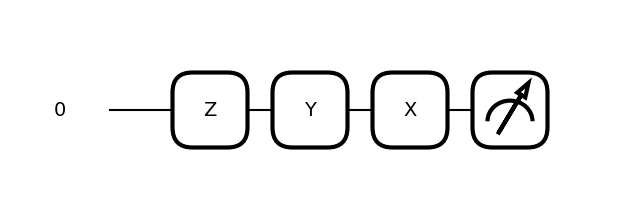

In [36]:
dev = qml.device('default.qubit', wires=1)

@qml.qnode(dev)
def circuit():
    qml.set_shots(1024)

    qml.PauliZ(wires=0)
    qml.PauliY(wires=0)
    qml.PauliX(wires=0)
    return qml.probs(wires=0)

fig, ax = qml.draw_mpl(circuit)()
fig.show()

In [37]:
print("Probabilities:", circuit())

Probabilities: [1. 0.]


## Task 2: 
Create a device with three qubits, and apply the Hadamard gate on all qubits and return the quantum state.

/var/folders/q8/wdys6cx112s2npsq3ry534m80000gn/T/ipykernel_76760/2091316549.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


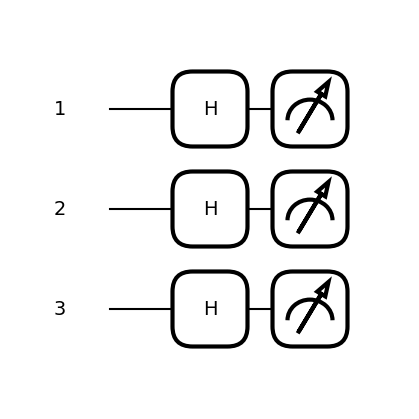

In [ ]:
dev = qml.device('default.qubit', wires=(1,2,3))

@qml.qnode(dev)
def circuit():
    qml.set_shots(1024)

    for i in range(1,4):
        qml.Hadamard(wires=i) # Apply Hadamard gate to each wire
    return qml.probs(wires=(1,2,3)) # Return probabilities for all wires (measure them)

fig, ax = qml.draw_mpl(circuit)()
fig.show()

In [41]:
print("Probabilities:", circuit())

Probabilities: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


## Task 3:
Create a circuit with two qubits and prepare an entangled state:
$$
\frac{|00\rangle - |11\rangle}{\sqrt 2}
$$

In [ ]:
print("Probabilities:", circuit())

Probabilities: [0. 1.]


## Built for Hybrid Quantum-Classical Computing

In [ ]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def circuit(params):
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def cost(params):
    return circuit(params)

params = np.array([0.54, 0.12])
opt = qml.GradientDescentOptimizer(stepsize=0.4)

for i in range(100):
    params = opt.step(cost, params)

print("Optimized rotation angles:", params)


Optimized rotation angles: [3.14159265 0.12      ]
